# 기본 설정

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, MinMaxScaler, RobustScaler, StandardScaler
from sklearn.impute import KNNImputer
import warnings
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import random
import sys
import os
from pathlib import Path
import joblib

warnings.filterwarnings('ignore')

In [16]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)

In [17]:
train = pd.read_csv('./open/train.csv')
test = pd.read_csv('./open/test.csv')

train.head(5)

,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,착상 전 유전 진단 사용 여부,남성 주 불임 원인,남성 부 불임 원인,여성 주 불임 원인,여성 부 불임 원인,부부 주 불임 원인,부부 부 불임 원인,불명확 불임 원인,불임 원인 - 난관 질환,불임 원인 - 남성 요인,불임 원인 - 배란 장애,불임 원인 - 여성 요인,불임 원인 - 자궁경부 문제,불임 원인 - 자궁내막증,불임 원인 - 정자 농도,불임 원인 - 정자 면역학적 요인,불임 원인 - 정자 운동성,불임 원인 - 정자 형태,배아 생성 주요 이유,총 시술 횟수,클리닉 내 총 시술 횟수,IVF 시술 횟수,DI 시술 횟수,총 임신 횟수,IVF 임신 횟수,DI 임신 횟수,총 출산 횟수,IVF 출산 횟수,DI 출산 횟수,총 생성 배아 수,미세주입된 난자 수,미세주입에서 생성된 배아 수,이식된 배아 수,미세주입 배아 이식 수,저장된 배아 수,미세주입 후 저장된 배아 수,해동된 배아 수,해동 난자 수,수집된 신선 난자 수,저장된 신선 난자 수,혼합된 난자 수,파트너 정자와 혼합된 난자 수,기증자 정자와 혼합된 난자 수,난자 출처,정자 출처,난자 기증자 나이,정자 기증자 나이,동결 배아 사용 여부,신선 배아 사용 여부,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,0.0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,현재 시술용,0회,0회,0회,0회,0회,0회,0회,0회,0회,0회,4.0,5.0,4.0,2.0,2.0,2.0,2.0,0.0,0.0,7.0,0.0,5.0,5.0,0.0,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.0,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,현재 시술용,0회,0회,0회,0회,0회,0회,0회,0회,0회,0회,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.0,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,0.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,현재 시술용,1회,0회,1회,0회,0회,0회,0회,0회,0회,0회,5.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,7.0,7.0,0.0,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.0,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,0.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,현재 시술용,1회,1회,1회,0회,0회,0회,0회,0회,0회,0회,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,4.0,4.0,0.0,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.0,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,현재 시술용,0회,0회,0회,0회,0회,0회,0회,0회,0회,0회,6.0,6.0,6.0,2.0,2.0,0.0,0.0,0.0,0.0,7.0,0.0,6.0,6.0,0.0,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.0,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


In [5]:
train.shape, test.shape

((256351, 69), (90067, 68))

In [33]:
(train["난자 기증자 나이"] == "알 수 없음").sum()
train.loc[train["난자 기증자 나이"] == "알 수 없음", "임신 성공 여부"].value_counts()

임신 성공 여부
0    180676
1     61705
Name: count, dtype: int64

In [6]:
train.describe()

,임신 시도 또는 마지막 임신 경과 연수,배란 자극 여부,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,착상 전 유전 진단 사용 여부,남성 주 불임 원인,남성 부 불임 원인,여성 주 불임 원인,여성 부 불임 원인,부부 주 불임 원인,부부 부 불임 원인,불명확 불임 원인,불임 원인 - 난관 질환,불임 원인 - 남성 요인,불임 원인 - 배란 장애,불임 원인 - 여성 요인,불임 원인 - 자궁경부 문제,불임 원인 - 자궁내막증,불임 원인 - 정자 농도,불임 원인 - 정자 면역학적 요인,불임 원인 - 정자 운동성,불임 원인 - 정자 형태,총 생성 배아 수,미세주입된 난자 수,미세주입에서 생성된 배아 수,이식된 배아 수,미세주입 배아 이식 수,저장된 배아 수,미세주입 후 저장된 배아 수,해동된 배아 수,해동 난자 수,수집된 신선 난자 수,저장된 신선 난자 수,혼합된 난자 수,파트너 정자와 혼합된 난자 수,기증자 정자와 혼합된 난자 수,동결 배아 사용 여부,신선 배아 사용 여부,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
count,9370.000000,256351.000000,250060.000000,2718.0,250060.000000,256351.000000,256351.000000,256351.000000,256351.000000,256351.000000,256351.000000,256351.000000,256351.000000,256351.000000,256351.000000,256351.0,256351.000000,256351.000000,256351.000000,256351.000000,256351.000000,256351.000000,250060.000000,250060.000000,250060.00000,250060.000000,250060.000000,250060.000000,250060.000000,250060.000000,250060.000000,250060.000000,250060.000000,250060.000000,250060.000000,250060.000000,250060.000000,250060.000000,250060.000000,250060.000000,2179.0,1929.0,198863.0,1436.000000,202616.000000,212785.000000,40369.000000,256351.000000
mean,9.270651,0.771286,0.233476,1.0,0.012781,0.028516,0.013115,0.030724,0.012432,0.033068,0.008765,0.250730,0.138704,0.372403,0.130392,0.0,0.000039,0.071394,0.001077,0.000004,0.000378,0.000558,5.061145,4.170799,2.84365,1.368156,0.724718,1.185975,0.612933,0.454571,0.046401,8.563717,0.093418,7.698928,7.107326,0.534728,0.160465,0.840342,0.009830,0.004195,1.0,1.0,0.0,0.001393,0.005385,3.254741,0.045629,0.258349
std,3.550313,0.420005,0.423043,0.0,0.112328,0.166441,0.113767,0.172568,0.110805,0.178814,0.093212,0.433434,0.345638,0.483446,0.336734,0.0,0.006246,0.257483,0.032795,0.001975,0.019449,0.023612,4.664337,5.625943,4.09464,0.771961,0.894352,2.502318,1.842522,1.415320,0.688246,7.317230,1.105882,6.451914,6.532466,2.509487,0.367038,0.366289,0.098656,0.064633,0.0,0.0,0.0,0.037307,0.111504,1.715697,0.418672,0.437728
min,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,2.000000,0.000000,0.000000
50%,9.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000,7.000000,6.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,3.000000,0.000000,0.000000
75%,11.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,7.000000,5.00000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,13.000000,0.000000,11.000000,11.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,5.000000,0.000000,1.000000
max,20.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,51.000000,51.000000,43.00000,3.000000,3.000000,51.000000,51.000000,32.000000,36.000000,51.000000,51.000000,51

In [7]:
train.columns

Index(['ID', '시술 시기 코드', '시술 당시 나이', '임신 시도 또는 마지막 임신 경과 연수', '시술 유형', '특정 시술 유형', '배란 자극 여부', '배란 유도 유형', '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인',
       '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도',
       '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '배아 생성 주요 이유', '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수',
       'DI 출산 횟수', '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수',
       '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수', '난자 출처', '정자 출처', '난자 기증자 나이', '정자 기증자 나이', '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부', '대리모 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 경과일', '난자 해동 경과일',
       '난자 혼합 경과일', '배아 이식 경과일', '

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 69 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     256351 non-null  object 
 1   시술 시기 코드               256351 non-null  object 
 2   시술 당시 나이               256351 non-null  object 
 3   임신 시도 또는 마지막 임신 경과 연수  9370 non-null    float64
 4   시술 유형                  256351 non-null  object 
 5   특정 시술 유형               256349 non-null  object 
 6   배란 자극 여부               256351 non-null  int64  
 7   배란 유도 유형               256351 non-null  object 
 8   단일 배아 이식 여부            250060 non-null  float64
 9   착상 전 유전 검사 사용 여부       2718 non-null    float64
 10  착상 전 유전 진단 사용 여부       250060 non-null  float64
 11  남성 주 불임 원인             256351 non-null  int64  
 12  남성 부 불임 원인             256351 non-null  int64  
 13  여성 주 불임 원인             256351 non-null  int64  
 14  여성 부 불임 원인             256351 non-nu

In [9]:

train["임신 성공 여부"].value_counts(normalize=True)


임신 성공 여부
0    0.741651
1    0.258349
Name: proportion, dtype: float64

In [10]:
def basic_overview(df, name="df"):
    print("\nMissing rate (top 10):")
    display(
        df.isnull().mean()
        .sort_values(ascending=False)
        .head(40)
    )

basic_overview(train, "train")



Missing rate (top 10):


난자 해동 경과일                0.994398
PGS 시술 여부                0.992475
PGD 시술 여부                0.991500
착상 전 유전 검사 사용 여부         0.989397
임신 시도 또는 마지막 임신 경과 연수    0.963449
배아 해동 경과일                0.842525
난자 채취 경과일                0.224255
난자 혼합 경과일                0.209615
배아 이식 경과일                0.169947
총 생성 배아 수                0.024541
저장된 신선 난자 수              0.024541
기증자 정자와 혼합된 난자 수         0.024541
파트너 정자와 혼합된 난자 수         0.024541
혼합된 난자 수                 0.024541
해동 난자 수                  0.024541
수집된 신선 난자 수              0.024541
이식된 배아 수                 0.024541
배아 생성 주요 이유              0.024541
해동된 배아 수                 0.024541
미세주입 배아 이식 수             0.024541
기증 배아 사용 여부              0.024541
미세주입에서 생성된 배아 수          0.024541
미세주입된 난자 수               0.024541
동결 배아 사용 여부              0.024541
신선 배아 사용 여부              0.024541
저장된 배아 수                 0.024541
대리모 여부                   0.024541
착상 전 유전 진단 사용 여부         0.024541
단일 배아 이식 여부              0.024541
미세주입 후 저장된 배아 

In [11]:
train.isnull().mean().sort_values(ascending=False).head(40)

난자 해동 경과일                0.994398
PGS 시술 여부                0.992475
PGD 시술 여부                0.991500
착상 전 유전 검사 사용 여부         0.989397
임신 시도 또는 마지막 임신 경과 연수    0.963449
배아 해동 경과일                0.842525
난자 채취 경과일                0.224255
난자 혼합 경과일                0.209615
배아 이식 경과일                0.169947
총 생성 배아 수                0.024541
저장된 신선 난자 수              0.024541
기증자 정자와 혼합된 난자 수         0.024541
파트너 정자와 혼합된 난자 수         0.024541
혼합된 난자 수                 0.024541
해동 난자 수                  0.024541
수집된 신선 난자 수              0.024541
이식된 배아 수                 0.024541
배아 생성 주요 이유              0.024541
해동된 배아 수                 0.024541
미세주입 배아 이식 수             0.024541
기증 배아 사용 여부              0.024541
미세주입에서 생성된 배아 수          0.024541
미세주입된 난자 수               0.024541
동결 배아 사용 여부              0.024541
신선 배아 사용 여부              0.024541
저장된 배아 수                 0.024541
대리모 여부                   0.024541
착상 전 유전 진단 사용 여부         0.024541
단일 배아 이식 여부              0.024541
미세주입 후 저장된 배아 

In [12]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()

print("수치형 컬럼 개수:", len(numeric_cols))
print("범주형 컬럼 개수:", len(categorical_cols))

수치형 컬럼 개수: 48
범주형 컬럼 개수: 21


In [13]:
numeric_cols

['임신 시도 또는 마지막 임신 경과 연수',
 '배란 자극 여부',
 '단일 배아 이식 여부',
 '착상 전 유전 검사 사용 여부',
 '착상 전 유전 진단 사용 여부',
 '남성 주 불임 원인',
 '남성 부 불임 원인',
 '여성 주 불임 원인',
 '여성 부 불임 원인',
 '부부 주 불임 원인',
 '부부 부 불임 원인',
 '불명확 불임 원인',
 '불임 원인 - 난관 질환',
 '불임 원인 - 남성 요인',
 '불임 원인 - 배란 장애',
 '불임 원인 - 여성 요인',
 '불임 원인 - 자궁경부 문제',
 '불임 원인 - 자궁내막증',
 '불임 원인 - 정자 농도',
 '불임 원인 - 정자 면역학적 요인',
 '불임 원인 - 정자 운동성',
 '불임 원인 - 정자 형태',
 '총 생성 배아 수',
 '미세주입된 난자 수',
 '미세주입에서 생성된 배아 수',
 '이식된 배아 수',
 '미세주입 배아 이식 수',
 '저장된 배아 수',
 '미세주입 후 저장된 배아 수',
 '해동된 배아 수',
 '해동 난자 수',
 '수집된 신선 난자 수',
 '저장된 신선 난자 수',
 '혼합된 난자 수',
 '파트너 정자와 혼합된 난자 수',
 '기증자 정자와 혼합된 난자 수',
 '동결 배아 사용 여부',
 '신선 배아 사용 여부',
 '기증 배아 사용 여부',
 '대리모 여부',
 'PGD 시술 여부',
 'PGS 시술 여부',
 '난자 채취 경과일',
 '난자 해동 경과일',
 '난자 혼합 경과일',
 '배아 이식 경과일',
 '배아 해동 경과일',
 '임신 성공 여부']

In [39]:
for col in categorical_cols:
    print(f"'{col}' 고유값 개수:", train[col].nunique(dropna=False))
    print(train[col].value_counts(dropna=False).head(21))

'ID' 고유값 개수: 256351
ID
TRAIN_000000    1
TRAIN_170906    1
TRAIN_170893    1
TRAIN_170894    1
TRAIN_170895    1
TRAIN_170896    1
TRAIN_170897    1
TRAIN_170898    1
TRAIN_170899    1
TRAIN_170900    1
TRAIN_170901    1
TRAIN_170902    1
TRAIN_170903    1
TRAIN_170904    1
TRAIN_170905    1
TRAIN_170907    1
TRAIN_170922    1
TRAIN_170908    1
TRAIN_170909    1
TRAIN_170910    1
TRAIN_170911    1
Name: count, dtype: int64
'시술 시기 코드' 고유값 개수: 7
시술 시기 코드
TRDQAZ    38969
TRCMWS    38090
TRYBLT    36713
TRVNRY    36173
TRJXFG    36031
TRZKPL    35544
TRXQMD    34831
Name: count, dtype: int64
'시술 당시 나이' 고유값 개수: 7
시술 당시 나이
만18-34세    102476
만35-37세     57780
만38-39세     39247
만40-42세     37348
만43-44세     12253
만45-50세      6918
알 수 없음        329
Name: count, dtype: int64
'시술 유형' 고유값 개수: 2
시술 유형
IVF    250060
DI       6291
Name: count, dtype: int64
'특정 시술 유형' 고유값 개수: 25
특정 시술 유형
ICSI                                   122368
IVF                                     91755
Unknown               

In [37]:
missing_count = train.isnull().sum().sort_values(ascending=False)
missing_count.head(40)

난자 해동 경과일                254915
PGS 시술 여부                254422
PGD 시술 여부                254172
착상 전 유전 검사 사용 여부         253633
임신 시도 또는 마지막 임신 경과 연수    246981
배아 해동 경과일                215982
난자 채취 경과일                 57488
난자 혼합 경과일                 53735
배아 이식 경과일                 43566
총 생성 배아 수                  6291
저장된 신선 난자 수                6291
기증자 정자와 혼합된 난자 수           6291
파트너 정자와 혼합된 난자 수           6291
혼합된 난자 수                   6291
해동 난자 수                    6291
수집된 신선 난자 수                6291
이식된 배아 수                   6291
배아 생성 주요 이유                6291
해동된 배아 수                   6291
미세주입 배아 이식 수               6291
기증 배아 사용 여부                6291
미세주입에서 생성된 배아 수            6291
미세주입된 난자 수                 6291
동결 배아 사용 여부                6291
신선 배아 사용 여부                6291
저장된 배아 수                   6291
대리모 여부                     6291
착상 전 유전 진단 사용 여부           6291
단일 배아 이식 여부                6291
미세주입 후 저장된 배아 수            6291
특정 시술 유형                      2
ID      

In [40]:
di_df  = train[train["시술 유형"] == "DI"]
ivf_df = train[train["시술 유형"] == "IVF"]

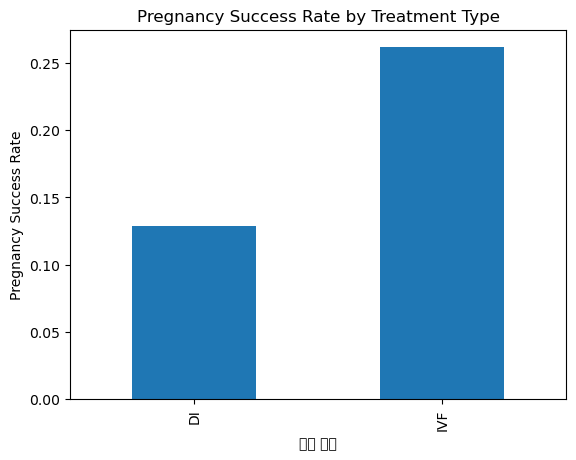

In [42]:
import matplotlib.pyplot as plt

success_rate = (train.groupby("시술 유형")['임신 성공 여부']
    .mean()
)

success_rate.plot(kind="bar")
plt.ylabel("Pregnancy Success Rate")
plt.title("Pregnancy Success Rate by Treatment Type")
plt.show()


In [43]:
unknown_age_df = train[train["시술 당시 나이"] == "알 수 없음"]

len(unknown_age_df)


329

In [44]:
unknown_age_df["임신 성공 여부"].value_counts(dropna=False)


임신 성공 여부
0    329
Name: count, dtype: int64

In [45]:
unknown_age_df["임신 성공 여부"].value_counts(normalize=True)


임신 성공 여부
0    1.0
Name: proportion, dtype: float64

In [14]:
for num in numeric_cols:
    print(f"'{num}' 고유값 개수:", train[col].nunique(dropna=False))
    print(train[num].value_counts(dropna=False).head(48))

NameError: name 'col' is not defined

In [50]:

treatment_col = "시술 유형"          # IVF / DI
male_primary_col = "남성 주 불임 원인"
male_secondary_col = "남성 부 불임 원인"
target_col = "임신 성공 여부"
di_df = train[train[treatment_col] == "DI"]

len(di_df)


6291

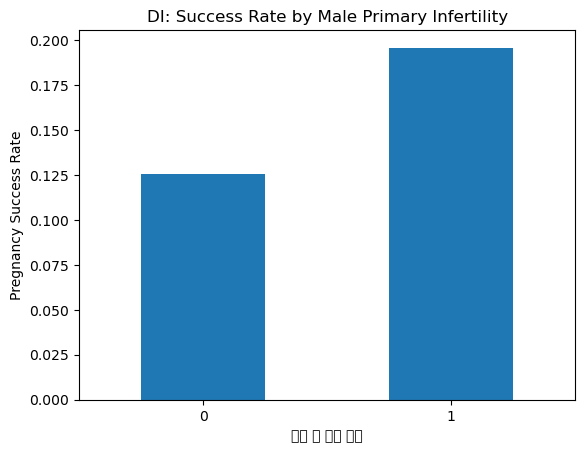

In [51]:
di_df.groupby(male_primary_col)[target_col].mean()


import matplotlib.pyplot as plt

rate_di_male_primary = di_df.groupby(male_primary_col)[target_col].mean()

rate_di_male_primary.plot(kind="bar")
plt.ylabel("Pregnancy Success Rate")
plt.title("DI: Success Rate by Male Primary Infertility")
plt.xticks(rotation=0)
plt.show()


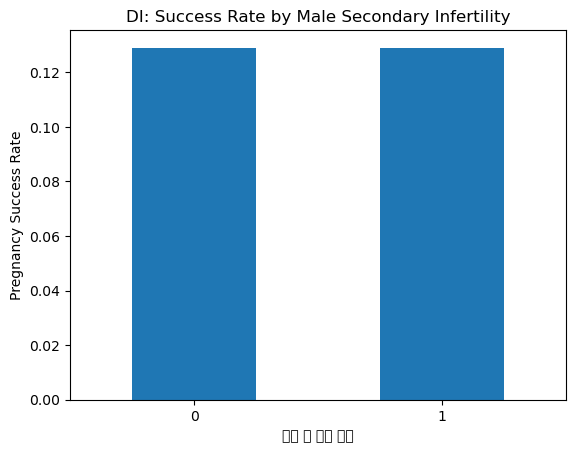

In [54]:
di_df.groupby(male_secondary_col)[target_col].mean()

rate_di_male_secondary = di_df.groupby(male_secondary_col)[target_col].mean()

rate_di_male_secondary.plot(kind="bar")
plt.ylabel("Pregnancy Success Rate")
plt.title("DI: Success Rate by Male Secondary Infertility")
plt.xticks(rotation=0)
plt.show()


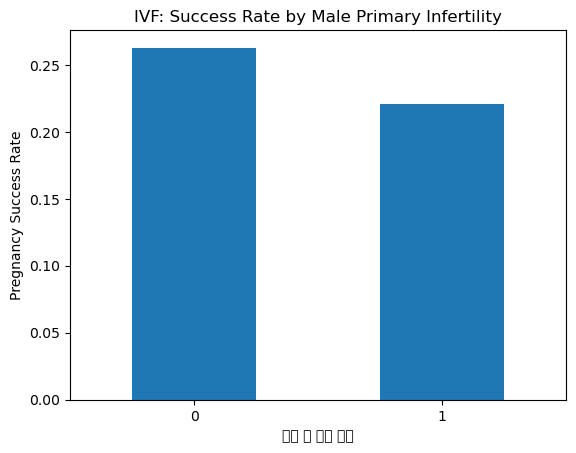

In [57]:
ivf_df = train[train[treatment_col] == "IVF"]

ivf_rate = (
    ivf_df
    .groupby(male_primary_col)[target_col]
    .mean()
)

ivf_rate.plot(kind="bar")
plt.ylabel("Pregnancy Success Rate")
plt.title("IVF: Success Rate by Male Primary Infertility")
plt.xticks(rotation=0)
plt.show()


In [58]:
male_factor_col   = "불임 원인 - 남성 요인"
sperm_count_col   = "불임 원인 - 정자 농도"
sperm_move_col    = "불임 원인 - 정자 운동성"
sperm_shape_col   = "불임 원인 - 정자 형태"
donor_egg_col     = "기증자 정자와 혼합된 난자 수"
target_col        = "임신 성공 여부"
treatment_col     = "시술 유형"   # DI / IVF


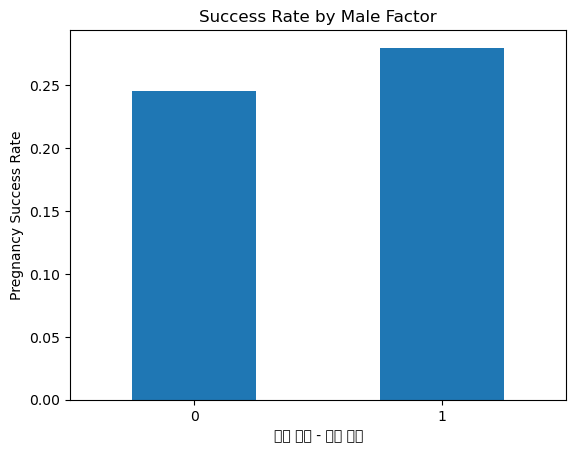

In [59]:
train.groupby(male_factor_col)[target_col].mean()

import matplotlib.pyplot as plt

train.groupby(male_factor_col)[target_col].mean().plot(kind="bar")
plt.ylabel("Pregnancy Success Rate")
plt.title("Success Rate by Male Factor")
plt.xticks(rotation=0)
plt.show()


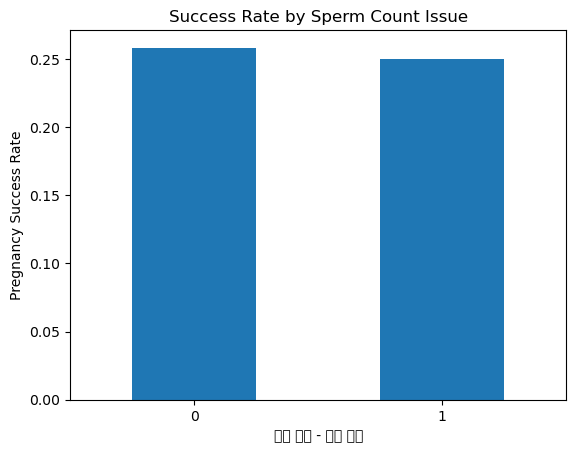

In [60]:
train.groupby(sperm_count_col)[target_col].mean()

train.groupby(sperm_count_col)[target_col].mean().plot(kind="bar")
plt.ylabel("Pregnancy Success Rate")
plt.title("Success Rate by Sperm Count Issue")
plt.xticks(rotation=0)
plt.show()


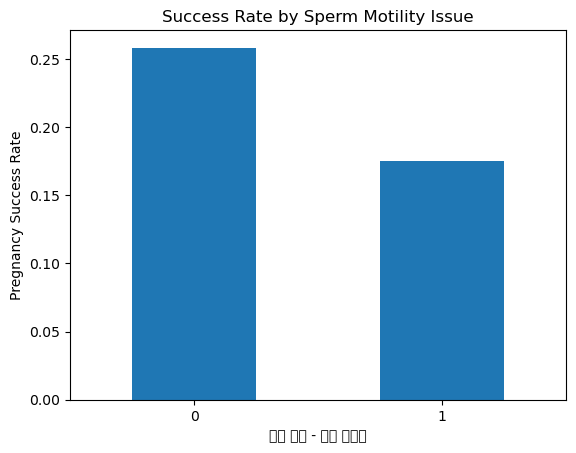

In [61]:
train.groupby(sperm_move_col)[target_col].mean()

train.groupby(sperm_move_col)[target_col].mean().plot(kind="bar")
plt.ylabel("Pregnancy Success Rate")
plt.title("Success Rate by Sperm Motility Issue")
plt.xticks(rotation=0)
plt.show()


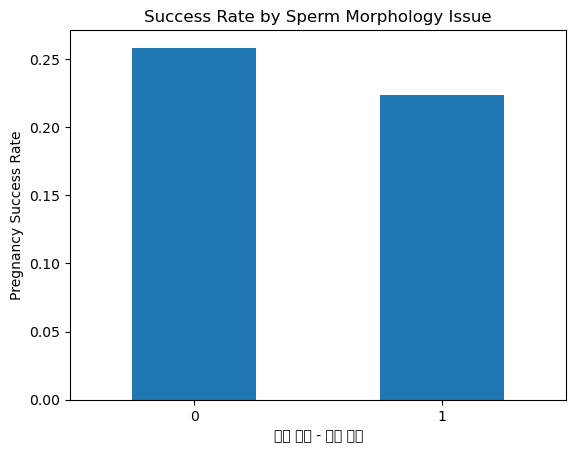

In [62]:
train.groupby(sperm_shape_col)[target_col].mean()
train.groupby(sperm_shape_col)[target_col].mean().plot(kind="bar")
plt.ylabel("Pregnancy Success Rate")
plt.title("Success Rate by Sperm Morphology Issue")
plt.xticks(rotation=0)
plt.show()


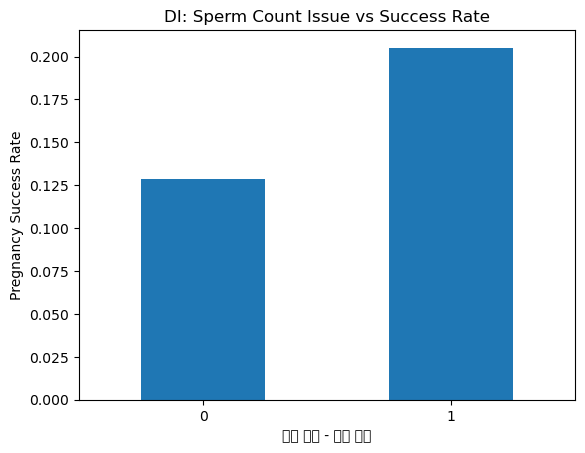

In [64]:
di_df = train[train[treatment_col] == "DI"]
di_df.groupby(sperm_count_col)[target_col].mean().plot(kind="bar")
plt.ylabel("Pregnancy Success Rate")
plt.title("DI: Sperm Count Issue vs Success Rate")
plt.xticks(rotation=0)
plt.show()



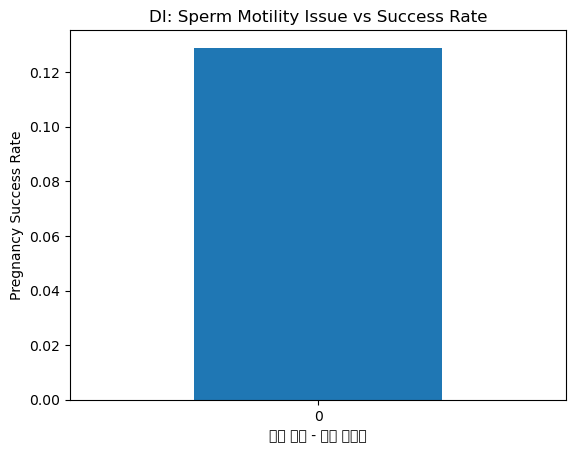

In [65]:
di_df.groupby(sperm_move_col)[target_col].mean().plot(kind="bar")
plt.ylabel("Pregnancy Success Rate")
plt.title("DI: Sperm Motility Issue vs Success Rate")
plt.xticks(rotation=0)
plt.show()


In [70]:
train[
    (train['배아 이식 경과일'] == 0) &
    (train['이식된 배아 수'] > 0)
].shape


(24900, 69)

In [72]:
missing_ratio = (
    train
    .isnull()
    .mean()
    .sort_values(ascending=False)
)

top9_cols = missing_ratio.head(9).index.tolist()
top9_cols


['난자 해동 경과일',
 'PGS 시술 여부',
 'PGD 시술 여부',
 '착상 전 유전 검사 사용 여부',
 '임신 시도 또는 마지막 임신 경과 연수',
 '배아 해동 경과일',
 '난자 채취 경과일',
 '난자 혼합 경과일',
 '배아 이식 경과일']

In [73]:
top10_30_cols = missing_ratio.iloc[9:30].index.tolist()
top10_30_cols

['총 생성 배아 수',
 '저장된 신선 난자 수',
 '기증자 정자와 혼합된 난자 수',
 '파트너 정자와 혼합된 난자 수',
 '혼합된 난자 수',
 '해동 난자 수',
 '수집된 신선 난자 수',
 '이식된 배아 수',
 '배아 생성 주요 이유',
 '해동된 배아 수',
 '미세주입 배아 이식 수',
 '기증 배아 사용 여부',
 '미세주입에서 생성된 배아 수',
 '미세주입된 난자 수',
 '동결 배아 사용 여부',
 '신선 배아 사용 여부',
 '저장된 배아 수',
 '대리모 여부',
 '착상 전 유전 진단 사용 여부',
 '단일 배아 이식 여부',
 '미세주입 후 저장된 배아 수']